# Fixed vs demand bag (1200 s) — DQN, PressLight, CoLight

## Why this experiment

Usual RL training on Grid4x4 replays the **same traffic file every episode**. Scores can look strong while the agent mostly **memorizes one movie**.

We treat it like **train vs test**:
- **Train** = demand the agent practices on
- **Test (held-out)** = unseen `hold_00…02`, no learning

| Arm | Training traffic |
|-----|------------------|
| **Fixed** | Same `fixed_1200.rou.xml` every episode |
| **Bag** | Rotate `train_00…09.rou.xml` |
| **MaxPressure** | No RL — flat reference on the same held-out files |

Agents: **DQN** (seeds 42, 43), **PressLight** and **CoLight** (seed 42).  
Setup: Grid4x4, **1200 s** episodes, **100** episodes, held-out every 10.

**Main question:** does bag training improve held-out ATT (and shrink the train−test gap) across more than one RL method?

In [15]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

REPO = Path('..').resolve()
OUT = REPO / 'data' / 'output_data' / 'tsc'
COLS = ['model', 'split', 'episode', 'travel_time', 'loss', 'reward', 'queue', 'delay', 'throughput']

RUNS = {
    ('DQN', 'fixed', 42): OUT / 'sumo_dqn_fixed1200' / 'sumo4x4' / 'dqn_fixed1200_s42' / 'logger',
    ('DQN', 'fixed', 43): OUT / 'sumo_dqn_fixed1200' / 'sumo4x4' / 'dqn_fixed1200_s43' / 'logger',
    ('DQN', 'bag', 42): OUT / 'sumo_dqn_bag1200' / 'sumo4x4' / 'dqn_bag1200_s42' / 'logger',
    ('DQN', 'bag', 43): OUT / 'sumo_dqn_bag1200' / 'sumo4x4' / 'dqn_bag1200_s43' / 'logger',
    ('PressLight', 'fixed', 42): OUT / 'sumo_presslight_fixed1200' / 'sumo4x4' / 'pl_fixed1200_s42' / 'logger',
    ('PressLight', 'bag', 42): OUT / 'sumo_presslight_bag1200' / 'sumo4x4' / 'pl_bag1200_s42' / 'logger',
    ('CoLight', 'fixed', 42): OUT / 'sumo_colight_fixed1200' / 'sumo4x4' / 'cl_fixed1200_s42' / 'logger',
    ('CoLight', 'bag', 42): OUT / 'sumo_colight_bag1200' / 'sumo4x4' / 'cl_bag1200_s42' / 'logger',
}
MP_LOGGER = OUT / 'sumo_maxpressure_1200' / 'sumo4x4' / 'mp_heldout_s42' / 'logger'


def load_dtl(logger_dir: Path) -> pd.DataFrame:
    paths = sorted(logger_dir.glob('*_DTL.log'))
    if not paths:
        raise FileNotFoundError(logger_dir)
    return pd.read_csv(paths[-1], sep='\t', header=None, names=COLS)


curves = []
for (agent, condition, seed), logger_dir in RUNS.items():
    df = load_dtl(logger_dir).assign(agent=agent, condition=condition, seed=seed)
    curves.append(df)
    print(f"{agent:10s} {condition:5s} seed={seed}  rows={len(df)}")

all_df = pd.concat(curves, ignore_index=True)
train = all_df[all_df.split == 'TRAIN'].copy()
heldout = all_df[all_df.split == 'HELDOUT_MEAN'].copy()

mp_df = load_dtl(MP_LOGGER)
MP_TEST_ATT = float(mp_df[mp_df.split == 'HELDOUT_MEAN'].iloc[-1].travel_time)
print(f"MaxPressure held-out mean ATT = {MP_TEST_ATT:.1f} s")

DQN        fixed seed=42  rows=144
DQN        fixed seed=43  rows=144
DQN        bag   seed=42  rows=144
DQN        bag   seed=43  rows=144
PressLight fixed seed=42  rows=144
PressLight bag   seed=42  rows=144
CoLight    fixed seed=42  rows=144
CoLight    bag   seed=42  rows=144
MaxPressure held-out mean ATT = 155.8 s


## 1. Train vs test by agent (seed 42)

Gray dotted line = MaxPressure on the same held-out files.

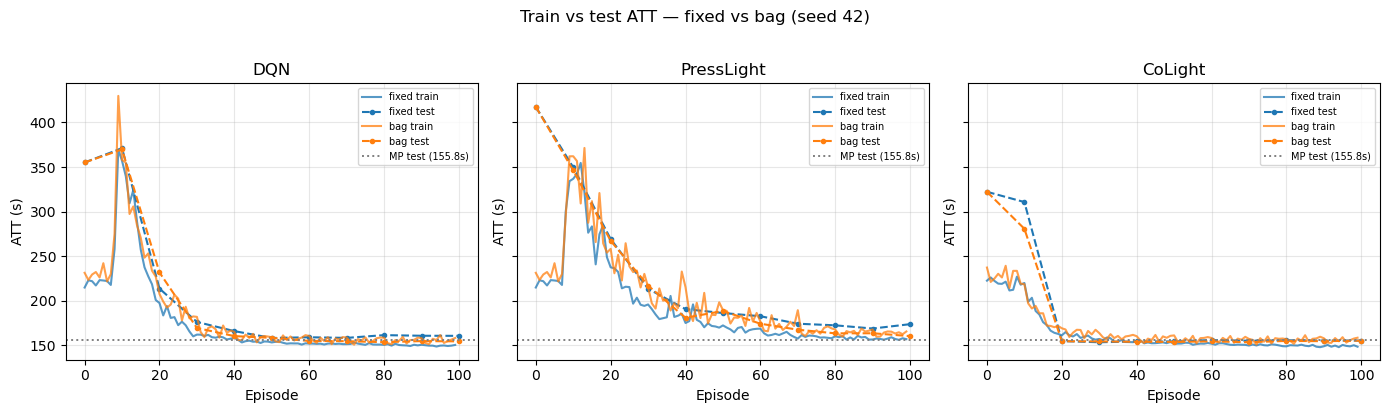

In [16]:
agents = ['DQN', 'PressLight', 'CoLight']
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, agent in zip(axes, agents):
    for condition, color in [('fixed', 'C0'), ('bag', 'C1')]:
        tr = train[(train.agent == agent) & (train.condition == condition) & (train.seed == 42)]
        te = heldout[(heldout.agent == agent) & (heldout.condition == condition) & (heldout.seed == 42)]
        ax.plot(tr.episode, tr.travel_time, color=color, ls='-', alpha=0.75, label=f'{condition} train')
        ax.plot(te.episode, te.travel_time, color=color, ls='--', marker='o', ms=3, label=f'{condition} test')
    ax.axhline(MP_TEST_ATT, color='gray', ls=':', lw=1.4, label=f'MP test ({MP_TEST_ATT:.1f}s)')
    ax.set_title(agent)
    ax.set_xlabel('Episode')
    ax.set_ylabel('ATT (s)')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc='upper right')

fig.suptitle('Train vs test ATT — fixed vs bag (seed 42)', y=1.02)
fig.tight_layout()
plt.show()

### Reading this figure

- Solid = train, dashed = test. Compare colors within each panel.
- **Fixed (blue):** train often ends below test → looks better on the practiced movie.
- **Bag (orange):** train and test stay closer; test often ends near/below train.
- Pattern appears for **DQN, PressLight, and CoLight**, not only one model.

## 2. Held-out (test) curves — all methods

This is the fair scoreboard. MaxPressure is the flat reference.

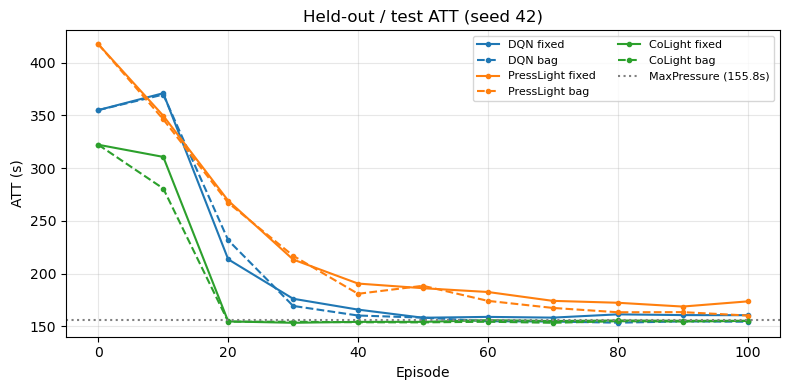

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
style = {
    ('DQN', 'fixed'): dict(color='C0', ls='-'),
    ('DQN', 'bag'): dict(color='C0', ls='--'),
    ('PressLight', 'fixed'): dict(color='C1', ls='-'),
    ('PressLight', 'bag'): dict(color='C1', ls='--'),
    ('CoLight', 'fixed'): dict(color='C2', ls='-'),
    ('CoLight', 'bag'): dict(color='C2', ls='--'),
}
for (agent, condition), kw in style.items():
    te = heldout[(heldout.agent == agent) & (heldout.condition == condition) & (heldout.seed == 42)]
    ax.plot(te.episode, te.travel_time, marker='o', ms=3, label=f'{agent} {condition}', **kw)

ax.axhline(MP_TEST_ATT, color='gray', ls=':', lw=1.5, label=f'MaxPressure ({MP_TEST_ATT:.1f}s)')
ax.set_title('Held-out / test ATT (seed 42)')
ax.set_xlabel('Episode')
ax.set_ylabel('ATT (s)')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

### Reading this figure

- Dashed (bag) ends at or below solid (fixed) for each color → bag wins or ties on test.
- PressLight **fixed** is the weakest held-out run; bag brings it closer to the pack / MP.
- DQN bag is the strongest held-out among these RL runs.

## 3. Generalization gap (test − train), seed 42

Above zero = worse on unseen demand than on train.

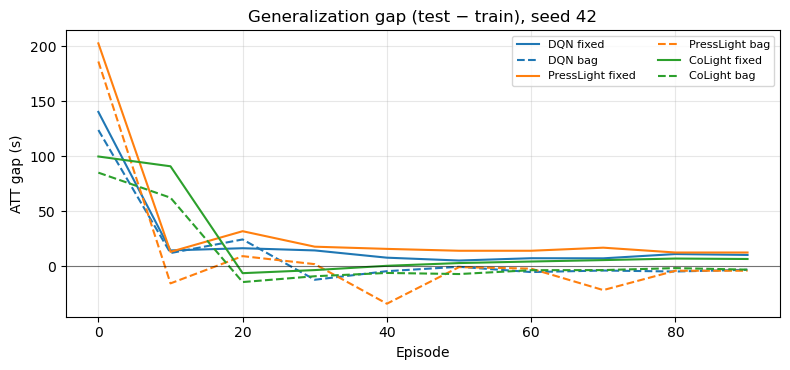

In [18]:
fig, ax = plt.subplots(figsize=(8, 3.8))
for agent, color in [('DQN', 'C0'), ('PressLight', 'C1'), ('CoLight', 'C2')]:
    for condition, ls in [('fixed', '-'), ('bag', '--')]:
        tr = train[(train.agent == agent) & (train.condition == condition) & (train.seed == 42)].set_index('episode')
        te = heldout[(heldout.agent == agent) & (heldout.condition == condition) & (heldout.seed == 42)].copy()
        te = te.assign(train_att=te.episode.map(tr['travel_time'])).dropna(subset=['train_att'])
        gap = te.travel_time - te.train_att
        ax.plot(te.episode, gap, color=color, ls=ls, label=f'{agent} {condition}')

ax.axhline(0, color='black', lw=0.8, alpha=0.5)
ax.set_title('Generalization gap (test − train), seed 42')
ax.set_xlabel('Episode')
ax.set_ylabel('ATT gap (s)')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

### Reading this figure

- **Fixed** lines end above zero for all three agents.
- **Bag** lines end at or below zero for all three.
- Same memorization-vs-transfer signature across methods.

## 4. Results table

In [19]:
rows = []
for (agent, condition, seed), logger_dir in RUNS.items():
    df = load_dtl(logger_dir)
    tr = df[df.split == 'TRAIN'].iloc[-1]
    te = df[df.split == 'HELDOUT_MEAN'].iloc[-1]
    train_att = float(tr.travel_time)
    test_att = float(te.travel_time)
    rows.append({
        'agent': agent,
        'condition': condition,
        'seed': seed,
        'final_train_ATT': round(train_att, 1),
        'final_test_ATT': round(test_att, 1),
        'gap (test−train)': round(test_att - train_att, 1),
        'vs_MP (test−MP)': round(test_att - MP_TEST_ATT, 1),
    })

results = pd.DataFrame(rows).sort_values(['agent', 'condition', 'seed']).reset_index(drop=True)
display(results)

# Seed-42 summary (fair multi-agent compare)
s42 = results[results.seed == 42].copy()
pivot = s42.pivot(index='agent', columns='condition', values=['final_train_ATT', 'final_test_ATT', 'gap (test−train)'])
print('Seed 42 pivot:')
display(pivot)

mp_row = pd.DataFrame([{
    'agent': 'MaxPressure',
    'condition': 'held-out only',
    'seed': 42,
    'final_train_ATT': None,
    'final_test_ATT': round(MP_TEST_ATT, 1),
    'gap (test−train)': None,
    'vs_MP (test−MP)': 0.0,
}])
print('MaxPressure reference:')
display(mp_row)

,agent,condition,seed,final_train_ATT,final_test_ATT,gap (test−train),vs_MP (test−MP)
0,CoLight,bag,42,158.5,155.2,-3.3,-0.6
1,CoLight,fixed,42,148.4,155.3,6.9,-0.5
2,DQN,bag,42,158.2,154.4,-3.8,-1.4
3,DQN,bag,43,159.0,153.2,-5.8,-2.6
4,DQN,fixed,42,150.4,160.6,10.2,4.8
5,DQN,fixed,43,150.1,157.8,7.7,2.0
6,PressLight,bag,42,165.5,160.3,-5.2,4.5
7,PressLight,fixed,42,156.9,173.7,16.8,17.9


Seed 42 pivot:


final_train_ATT        final_test_ATT        gap (test−train)      
condition              bag  fixed            bag  fixed              bag fixed
agent                                                                         
CoLight              158.5  148.4          155.2  155.3             -3.3   6.9
DQN                  158.2  150.4          154.4  160.6             -3.8  10.2
PressLight           165.5  156.9          160.3  173.7             -5.2  16.8

MaxPressure reference:


,agent,condition,seed,final_train_ATT,final_test_ATT,gap (test−train),vs_MP (test−MP)
0,MaxPressure,held-out only,42,None,155.8,None,0.0


## 5. Findings summary

Final seed-42 numbers (lower ATT better):

| Agent | Fixed train → test | Bag train → test | Gap fixed | Gap bag | Test winner |
|-------|--------------------|------------------|-----------|---------|-------------|
| **DQN** | 150.4 → **160.6** | 158.2 → **154.4** | +10.2 | −3.8 | **bag** (best overall test) |
| **PressLight** | 156.9 → **173.7** | 165.5 → **160.3** | +16.8 | −5.2 | **bag** |
| **CoLight** | 148.4 → **155.3** | 158.5 → **155.2** | +6.9 | −3.3 | **bag** (tie-ish on test, better gap) |
| **MaxPressure** | — → **155.8** | — | — | — | reference |

### What this shows

1. **Fixed looks better on train, worse on test** for DQN, PressLight, and CoLight (positive gaps).
2. **Bag improves generalization**: negative gaps and better (or equal) held-out ATT for every agent.
3. This is **not DQN-only** — same protocol effect across three RL methods.
4. Against **MaxPressure (~155.8)**: DQN bag is slightly better; CoLight lands near MP; PressLight fixed is clearly worse, PressLight bag closer.
5. **Train-only leaderboards would mislead** (they favor fixed).

### One-line claim

On Grid4x4 with held-out demand, training on one fixed traffic movie overstates RL learning; a rotating demand bag + held-out eval flips or improves the ranking toward real transfer, consistently across DQN, PressLight, and CoLight.

Background: `extras/DEMAND_BAG_EXPERIMENT.md`.